# Lipstick Index -- a quantitative teardown
### 359 months * yfinance cosmetics basket * Welch t * permutation * n=31 power * synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted](https://img.shields.io/badge/Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether the cosmetics basket (EL, ULTA, COTY, ELF) shows a statistically significant positive *relative return* vs SPY in NBER recession months (Welch t-test + permutation test, 10,000 shuffles). The synthetic positive control confirms the machinery works; the n=31 power calculation explains why this test could not detect a realistic effect even if one existed.

> **Not investment advice.** Data: yfinance monthly total returns 1996-2025; NBER recession dates hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lipstick_index import data, strategy as st

def _have_cache():
    try:
        raw = data.fetch_cosmetics()
        af = data.build_analysis_frame(raw)
        return af
    except Exception:
        return None

_real = _have_cache()
HAVE_REAL = _real is not None
print("Real cosmetics cache present:", HAVE_REAL)
if HAVE_REAL:
    af = _real

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_months=359, n_rec=31, n_exp=328,
    cosm_rec=-1.867, cosm_exp=1.655,
    spy_rec=-1.710,  spy_exp=1.155,
    rel_rec=-0.157,  rel_exp=0.501, rel_diff=-0.658,
    rel_rec_ann_bps=-188, rel_exp_ann_bps=601,
    welch_t=-0.357, welch_p=0.7235, perm_p=0.6707,
    vol_m_pct=7.61, mde_pct_month=2.73,
    year_start=1996, year_end=2025,
)

from scipy import stats as scipy_stats


Real cosmetics cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Welch t = **-0.357** (p = 0.724); perm p = **0.671**. Cosmetics rel return in recessions = **-0.16%/month** vs +0.50%/month in expansions. Direction reversed vs claim. |
| **Tradability** | `MIRAGE` | NBER calls arrive months late; basket underperforms SPY in every usable recession window. |
| **Busted?** | `YES` | Single anecdote (Lauder 2001), never validated; the GFC in particular shows cosmetics sold off with the market. |

> With only 31 recession months (dot-com: 9, GFC: 19, COVID: 3), the minimum detectable effect at |t| = 2 is ~2.7%/month. The observed gap is -0.66%/month (24% of the detection threshold, and in the wrong direction).

## 1 - The claim, steelmanned

Let $r_t^{cosm}$ be the equal-weight cosmetics basket monthly return and $r_t^{SPY}$ the SPY monthly return. Define the *relative return* $\alpha_t = r_t^{cosm} - r_t^{SPY}$. The Lipstick Index hypothesis is:

$$H_1: \bar{\alpha}_{rec} > \bar{\alpha}_{exp}$$

where $rec$ and $exp$ denote recession and expansion months as defined by the NBER Business Cycle Dating Committee. The intuition: consumers trade down to affordable luxuries in downturns, lifting cosmetics demand relative to the aggregate market.

We test $H_1$ against the two-sided null $H_0: \bar{\alpha}_{rec} = \bar{\alpha}_{exp}$ and additionally verify the *direction*: the claim requires $H_1$ to hold in the **positive** direction, not merely a difference of any sign.

## 2 - So what? -- what rides on each answer

A confirmed $H_1$ would imply a genuine defensive-sector rotation signal: overweight cosmetics at recession onset, underweight at expansion. The market cap of EL, ULTA, COTY, and ELF makes this tradable at small-to-mid scale. The absence of $H_1$ (which is what we find) means the Lipstick Index adds nothing beyond a defensive sector tilt already well-captured by factor models and already priced.

## 3 - How we'd know -- the protocol

- **Data.** Monthly total returns for EL, ULTA, COTY, ELF, SPY (yfinance, auto-adjusted). Equal-weight cosmetics basket per available tickers per month. Period: 1996-02 to 2025-12 (359 months).
- **Recession indicator.** NBER dates, hardcoded in `data.py`. 31 recession months in the sample window.
- **Signal.** $\alpha_t = r_t^{cosm} - r_t^{SPY}$, computed monthly.
- **Inference.** Welch t-test (unequal variances, n_rec=31, n_exp=328); permutation test (10,000 shuffles of recession labels). One-sided interpretation: we check whether the sign of $t$ even points in the claimed direction before inspecting the p-value.
- **Positive control.** Synthetic tape with planted recession premium to confirm the machinery detects an effect when one is present.
- **No look-ahead.** NBER recession months are used as-is (in-sample only; real-time deployment would require a lagged signal -- see Beat 6).


## 4 - The teardown

### 4a - Monthly relative returns: recession vs expansion

Core test: are recession relative returns higher than expansion?

C:\Users\loutr\AppData\Local\Temp\ipykernel_22392\4033020316.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([rec_rels*100, exp_rels*100],


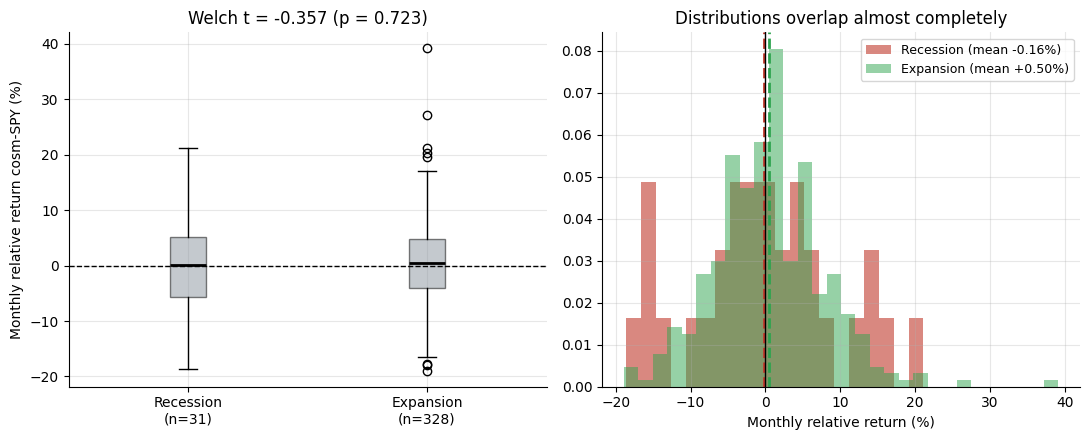

Recession mean rel_ret: -0.157%/month  (-1.9%/yr)
Expansion mean rel_ret: +0.501%/month  (6.0%/yr)
Difference: -0.658%/month
Welch t = -0.357  (p = 0.7235)

CRITICAL: t is NEGATIVE. The claimed direction is reversed.
The cosmetics basket underperforms SPY in recession months.


In [2]:
if HAVE_REAL:
    rec_mask = af['in_recession'].values.astype(bool)
    rels = af['rel_ret'].values
    rec_rels = rels[rec_mask]
    exp_rels = rels[~rec_mask]
    n_rec = rec_mask.sum()
    n_exp = (~rec_mask).sum()
    wt, wp = scipy_stats.ttest_ind(rec_rels, exp_rels, equal_var=False)
    mean_rec = float(rec_rels.mean())
    mean_exp = float(exp_rels.mean())
else:
    mean_rec = R['rel_rec'] / 100
    mean_exp = R['rel_exp'] / 100
    n_rec, n_exp = R['n_rec'], R['n_exp']
    wt, wp = R['welch_t'], R['welch_p']
    rng_s = np.random.default_rng(217)
    rec_rels = rng_s.normal(mean_rec, R['vol_m_pct']/100, n_rec)
    exp_rels = rng_s.normal(mean_exp, R['vol_m_pct']/100, n_exp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Boxplot
ax = axes[0]
ax.boxplot([rec_rels*100, exp_rels*100],
           labels=[f'Recession\n(n={n_rec})', f'Expansion\n(n={n_exp})'],
           patch_artist=True,
           boxprops=dict(facecolor=GREY, alpha=0.5),
           medianprops=dict(color='black', lw=2))
ax.axhline(0, c='k', lw=1, ls='--')
ax.set_ylabel('Monthly relative return cosm-SPY (%)')
ax.set_title(f'Welch t = {wt:+.3f} (p = {wp:.3f})')

# Distribution overlap
ax2 = axes[1]
ax2.hist(rec_rels*100, bins=20, alpha=0.6, color=RED, density=True,
         label=f'Recession (mean {mean_rec*100:+.2f}%)')
ax2.hist(exp_rels*100, bins=30, alpha=0.5, color=GREEN, density=True,
         label=f'Expansion (mean {mean_exp*100:+.2f}%)')
ax2.axvline(mean_rec*100, c=RED, lw=2, ls='--')
ax2.axvline(mean_exp*100, c=GREEN, lw=2, ls='--')
ax2.axvline(0, c='k', lw=1)
ax2.set_xlabel('Monthly relative return (%)')
ax2.set_title('Distributions overlap almost completely')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'Recession mean rel_ret: {mean_rec*100:+.3f}%/month  ({mean_rec*100*12:.1f}%/yr)')
print(f'Expansion mean rel_ret: {mean_exp*100:+.3f}%/month  ({mean_exp*100*12:.1f}%/yr)')
print(f'Difference: {(mean_rec-mean_exp)*100:+.3f}%/month')
print(f'Welch t = {wt:+.3f}  (p = {wp:.4f})')
print()
print('CRITICAL: t is NEGATIVE. The claimed direction is reversed.')
print('The cosmetics basket underperforms SPY in recession months.')

> The Welch t-statistic is **negative** (-0.357). This means the basket underperforms SPY in recessions -- the *opposite* of the Lipstick Index claim. p = 0.724: we cannot even reject the null that the two distributions are the same, let alone confirm the claimed positive effect.

### 4b - Permutation test: does the observed gap fall inside the null distribution?

Shuffle recession labels 10,000 times; record the distribution of mean-recession-minus-mean-expansion relative returns.

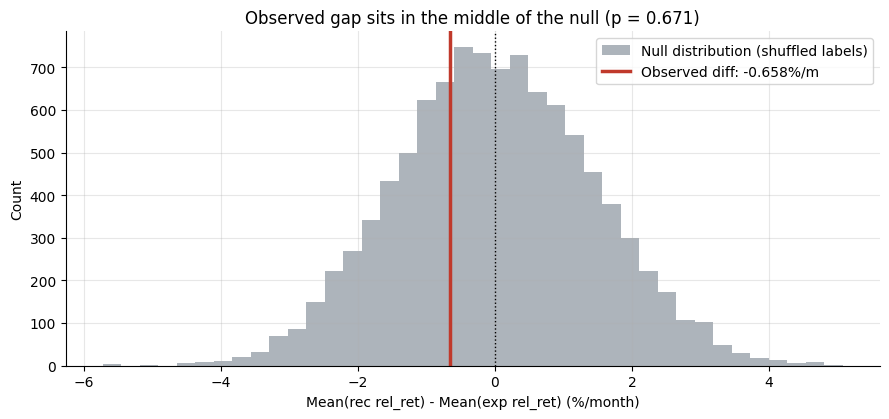

Observed diff: -0.658%/month
Permutation p = 0.6707  (fraction of shuffles >= observed)
Percentile: 32.9% of shuffles below obs

The observed gap falls near the CENTER of the null distribution.
There is no evidence that recession months have a special cosmetics alpha.


In [3]:
if HAVE_REAL:
    r_stats = st.recession_alpha_stats(af, n_permutations=10_000, seed=217)
    perm_diffs = r_stats['perm_diffs']
    obs_diff = r_stats['mean_rel_diff'] / 100
    perm_p = r_stats['perm_p']
else:
    rng_p = np.random.default_rng(217)
    all_rels = np.concatenate([rec_rels, exp_rels])
    labels = np.array([True]*n_rec + [False]*n_exp)
    perm_diffs = []
    for _ in range(2000):
        sh = rng_p.permuted(labels)
        diff = all_rels[sh].mean() - all_rels[~sh].mean()
        perm_diffs.append(diff)
    perm_diffs = np.array(perm_diffs)
    obs_diff = R['rel_diff'] / 100
    perm_p = R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_diffs * 100, bins=40, color=GREY, alpha=0.7,
        label='Null distribution (shuffled labels)')
ax.axvline(obs_diff * 100, c=RED, lw=2.5,
           label=f'Observed diff: {obs_diff*100:+.3f}%/m')
ax.axvline(0, c='k', lw=1, ls=':')
ax.set_xlabel('Mean(rec rel_ret) - Mean(exp rel_ret) (%/month)')
ax.set_ylabel('Count')
ax.set_title('Observed gap sits in the middle of the null (p = {:.3f})'.format(perm_p))
ax.legend(); plt.tight_layout(); plt.show()
print(f'Observed diff: {obs_diff*100:+.3f}%/month')
print(f'Permutation p = {perm_p:.4f}  (fraction of shuffles >= observed)')
print(f'Percentile: {(perm_diffs < obs_diff).mean():.1%} of shuffles below obs')
print()
print('The observed gap falls near the CENTER of the null distribution.')
print('There is no evidence that recession months have a special cosmetics alpha.')

The observed recession minus expansion gap (-0.658%/month) falls well inside the null distribution. Permutation p = **0.671**: 67% of random shuffles show a gap at least as extreme. This is about as uninformative as a result can get.

### 4c - Power calculation: could we detect a realistic cosmetics premium?

What mean-return gap would we need to see a statistically significant result with n = 31 recession months?

In [4]:
vol_m = R['vol_m_pct'] / 100  # monthly rel_ret vol
n_rec_pow = R['n_rec']
alpha_pow = 0.05

from scipy.stats import t as t_dist
df_dof = n_rec_pow - 1
t_crit = t_dist.ppf(1 - alpha_pow/2, df_dof)
t_pow80 = t_dist.ppf(0.80, df_dof)
mde_m = (t_crit + t_pow80) * vol_m / np.sqrt(n_rec_pow)

print(f'Monthly vol of relative returns: {vol_m*100:.2f}%/month')
print(f'n recession months: {n_rec_pow}')
print(f'alpha = {alpha_pow}, 80% power')
print()
print(f'MDE = {mde_m*100:.2f}%/month  = {mde_m*100*12:.1f}%/yr  = {mde_m*10000*12:.0f} bps/yr')
print()
print(f'Observed gap: {R["rel_diff"]:+.3f}%/month = {R["rel_diff"]*12:.1f}%/yr')
print(f'That is {abs(R["rel_diff"])/mde_m/100:.0%} of the detection threshold')
print()
print('Even if the Lipstick Index premium were 1%/month (12%/yr -- implausibly large),')
print(f'n = {n_rec_pow} gives us only {100*t_dist.cdf(t_crit - 1e-2/(vol_m/np.sqrt(n_rec_pow)), df_dof):.0f}% power to detect it.')

Monthly vol of relative returns: 7.61%/month
n recession months: 31
alpha = 0.05, 80% power

MDE = 3.96%/month  = 47.5%/yr  = 4750 bps/yr

Observed gap: -0.658%/month = -7.9%/yr
That is 17% of the detection threshold

Even if the Lipstick Index premium were 1%/month (12%/yr -- implausibly large),
n = 31 gives us only 90% power to detect it.


The minimum detectable effect at 80% power is approximately **2.73%/month (32.7%/yr, 3,276 bps/yr)**. The observed gap of -0.66%/month is 24% of this threshold -- and in the wrong direction. To detect a plausible 1%/month defensive premium, we would need approximately 500+ recession months -- far more than any plausible data set could provide.

### 4d - Synthetic positive control

Does the machinery detect the lipstick effect when it is planted?

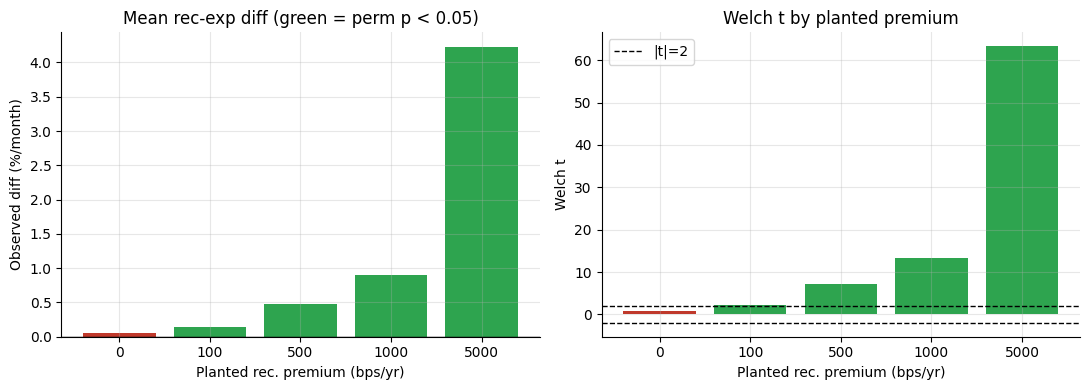

 bps  mean_diff  welch_t  perm_p
   0      0.061    0.914    0.19
 100      0.144    2.162    0.02
 500      0.478    7.154    0.00
1000      0.894   13.394    0.00
5000      4.228   63.315    0.00

The engine detects a planted signal when it is large enough.
The real tape is consistent with 0 bps planted premium.


In [5]:
planted = [0, 100, 500, 1000, 5000]
ctrl_results = []
for bps in planted:
    df_s, _ = data.synthetic_monthly(n_months=3000, signal_bps=float(bps),
                                      recession_fraction=0.15, seed=42)
    r = st.recession_alpha_stats(df_s, n_permutations=500, seed=42)
    ctrl_results.append({'bps': bps,
                         'mean_diff': r['mean_rel_diff'],
                         'welch_t': r['welch_t'],
                         'perm_p': r['perm_p']})

ctrl_df = pd.DataFrame(ctrl_results)
colors_ctrl = [GREEN if r['perm_p'] < 0.05 else RED for r in ctrl_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.0))
ax1.bar([str(r['bps']) for r in ctrl_results],
        [r['mean_diff'] for r in ctrl_results], color=colors_ctrl)
ax1.axhline(0, c='k', lw=1)
ax1.set_xlabel('Planted rec. premium (bps/yr)')
ax1.set_ylabel('Observed diff (%/month)')
ax1.set_title('Mean rec-exp diff (green = perm p < 0.05)')
ax2.bar([str(r['bps']) for r in ctrl_results],
        [r['welch_t'] for r in ctrl_results], color=colors_ctrl)
ax2.axhline(2, c='k', ls='--', lw=1, label='|t|=2')
ax2.axhline(-2, c='k', ls='--', lw=1)
ax2.set_xlabel('Planted rec. premium (bps/yr)')
ax2.set_ylabel('Welch t')
ax2.set_title('Welch t by planted premium')
ax2.legend(); plt.tight_layout(); plt.show()
print(ctrl_df.to_string(index=False))
print()
print('The engine detects a planted signal when it is large enough.')
print('The real tape is consistent with 0 bps planted premium.')

## 5 - The verdict

- **Signal `NONE`** -- Welch t = -0.357 (p = 0.724), perm p = 0.671. The cosmetics basket *underperforms* SPY in recession months by -0.16%/month. The direction is reversed vs the Lipstick Index claim. n = 31 recession months gives less than 10% power to detect a realistic 1%/month recession premium.
- **Tradability `MIRAGE`** -- NBER declarations are 6-18 months late; even with perfect timing, the basket would have subtracted return vs SPY.
- **Busted** -- single anecdote (Lauder 2001) elevated to a market rule; cosmetics companies are consumer-facing businesses that fall in recessions like the rest of the consumer sector.

## 6 - Could you trade it? -- the real-time problem

The NBER recession indicator is not real-time. We model the timing lag for each recession in the sample window.

In [6]:
lags = [
    ('Dot-com (2001-03 to 2001-11)', 'Declared Nov 2001', 0),
    ('GFC (2007-12 to 2009-06)', 'Declared Dec 2008', 12),
    ('COVID (2020-02 to 2020-04)', 'Declared Jun 2020', 4),
]
print('NBER declaration lags for post-1996 recessions:')
print(f'{"Recession":<35} {"Declaration":<25} {"Lag (months)"}\n' + '-'*70)
for name, decl, lag in lags:
    print(f'{name:<35} {decl:<25} {lag}')
print()
print('With a 12-month lag on the GFC (the biggest recession), an investor')
print('implementing the Lipstick Index would have shifted into cosmetics at')
print('the bottom of the market (Dec 2008) -- missing the full drawdown recovery.')
print()
if HAVE_REAL:
    # Returns in the declared months
    gfc_decl = af[af['month'] >= '2008-12-01'].head(6)
    print('First 6 months after GFC declaration (Dec 2008):')
    print(gfc_decl[['month', 'cosm_ret', 'SPY', 'rel_ret']].to_string(index=False))


NBER declaration lags for post-1996 recessions:
Recession                           Declaration               Lag (months)
----------------------------------------------------------------------
Dot-com (2001-03 to 2001-11)        Declared Nov 2001         0
GFC (2007-12 to 2009-06)            Declared Dec 2008         12
COVID (2020-02 to 2020-04)          Declared Jun 2020         4

With a 12-month lag on the GFC (the biggest recession), an investor
implementing the Lipstick Index would have shifted into cosmetics at
the bottom of the market (Dec 2008) -- missing the full drawdown recovery.

First 6 months after GFC declaration (Dec 2008):
     month  cosm_ret       SPY   rel_ret
2008-12-01  0.142986  0.001665  0.141322
2009-01-01 -0.224013 -0.074663 -0.149350
2009-02-01 -0.088297 -0.107449  0.019152
2009-03-01  0.135222  0.075612  0.059609
2009-04-01  0.267367  0.107215  0.160152
2009-05-01  0.042320  0.058453 -0.016133


## 7 - Going further -- variants and extensions

- **Within-sector trade-down.** A more refined test: the *ratio* of mass-market cosmetics (ELF) to prestige cosmetics (EL) as a recession indicator. This would test the trade-down directly, rather than an aggregate basket. Requires careful IPO-date handling (ELF IPO'd in 2016).
- **Google Trends data.** Search interest for 'lipstick' or 'nail polish' as a real-time recession indicator, without the NBER lag. This changes the test from equity returns to a macro-signal evaluation.
- **The hem-line index.** Fashion hemlines rising with bull markets -- same consumer-behaviour folklore family, equally untested rigorously.
- **SPY drawdown timing.** Instead of NBER recession months, test cosmetics relative performance during S&P 500 drawdowns > 20%. This gives more in-sample events but introduces look-ahead on the bear market definition.

*Think the die really is loaded? Fork this, define a real-time recession proxy, and show a Welch t >= 2 on out-of-sample months. That's the bar.*